In [1]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "text.color":        "black",
    "axes.labelcolor":   "black",
    "axes.edgecolor":    "#aaaaaa",
    "xtick.color":       "#aaaaaa",
    "ytick.color":       "#c84d4d",
    "grid.color":        "#e8e8e3",
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#dddddd",
})

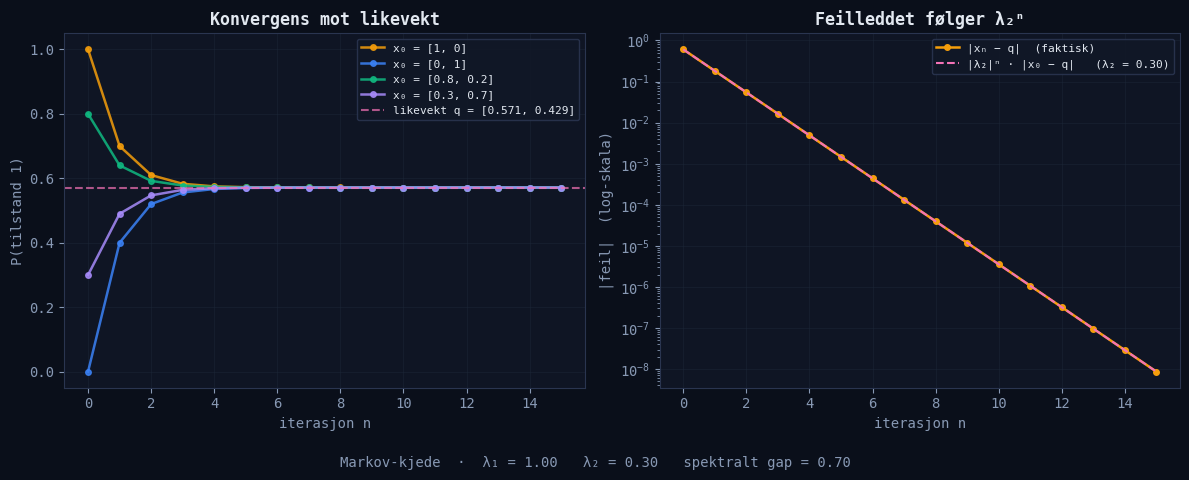

In [2]:
import matplotlib.pyplot as plt
plt.close('all')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Overgangsmatrise (kolonne-stokastisk) ---
P = np.array([
    [0.7, 0.4],
    [0.3, 0.6]
])

# --- Egenverdier og likevektsvektor ---
eigenvalues, eigenvectors = np.linalg.eig(P)

# Finn egenvektoren med λ = 1 og normaliser til sannsynlighetsvektor
idx = np.argmin(np.abs(eigenvalues - 1))
steady = np.real(eigenvectors[:, idx])
steady = steady / steady.sum()

lambda2 = eigenvalues[1 - idx]

# --- Iterasjon fra ulike startvektorer ---
starts = [
    np.array([1.0, 0.0]),
    np.array([0.0, 1.0]),
    np.array([0.8, 0.2]),
    np.array([0.3, 0.7]),
]
labels = ["[1, 0]", "[0, 1]", "[0.8, 0.2]", "[0.3, 0.7]"]
colors = ["#f59e0b", "#3b82f6", "#10b981", "#a78bfa"]

n_steps = 15

def iterate(P, x0, n):
    trajectory = [x0.copy()]
    x = x0.copy()
    for _ in range(n):
        x = P @ x
        trajectory.append(x.copy())
    return np.array(trajectory)

trajectories = [iterate(P, s, n_steps) for s in starts]

# --- Plotting ---
mpl.rcParams.update({
    "font.family": "monospace",
    "font.size": 10,
    "axes.facecolor": "#0f1524",
    "figure.facecolor": "#0a0f1a",
    "text.color": "#e2e8f0",
    "axes.edgecolor": "#2a3550",
    "axes.labelcolor": "#8899b4",
    "xtick.color": "#8899b4",
    "ytick.color": "#8899b4",
    "grid.color": "#1e293b",
    "grid.alpha": 0.6,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Konvergens mot likevekt ---
ax = axes[0]
ns = np.arange(n_steps + 1)

for traj, label, color in zip(trajectories, labels, colors):
    ax.plot(ns, traj[:, 0], "o-", color=color, label=f"x₀ = {label}",
            markersize=4, linewidth=1.8, alpha=0.85)

ax.axhline(y=steady[0], color="#f472b6", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"likevekt q = [{steady[0]:.3f}, {steady[1]:.3f}]")

ax.set_xlabel("iterasjon n")
ax.set_ylabel("P(tilstand 1)")
ax.set_title("Konvergens mot likevekt", color="#e2e8f0", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, facecolor="#111827", edgecolor="#2a3550", labelcolor="#e2e8f0")
ax.grid(True, linewidth=0.5)
ax.set_ylim(-0.05, 1.05)

# --- Plot 2: Feilleddet vs λ₂ⁿ ---
ax2 = axes[1]

traj = trajectories[0]  # bruker x₀ = [1, 0]
errors = np.linalg.norm(traj - steady, axis=1)
theoretical = errors[0] * np.abs(lambda2) ** ns

ax2.semilogy(ns, errors, "o-", color="#f59e0b", markersize=4,
             linewidth=1.8, label="|xₙ − q|  (faktisk)")
ax2.semilogy(ns, theoretical, "--", color="#f472b6",
             linewidth=1.5, label=f"|λ₂|ⁿ · |x₀ − q|   (λ₂ = {np.real(lambda2):.2f})")

ax2.set_xlabel("iterasjon n")
ax2.set_ylabel("|feil|  (log-skala)")
ax2.set_title("Feilleddet følger λ₂ⁿ", color="#e2e8f0", fontsize=12, fontweight="bold")
ax2.legend(fontsize=8, facecolor="#111827", edgecolor="#2a3550", labelcolor="#e2e8f0")
ax2.grid(True, linewidth=0.5)

# --- Info-tekst ---
fig.suptitle(
    f"Markov-kjede  ·  λ₁ = {np.real(eigenvalues[idx]):.2f}   λ₂ = {np.real(lambda2):.2f}   spektralt gap = {1 - abs(lambda2):.2f}",
    color="#8899b4", fontsize=10, y=0.02
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Ortogonal projeksjon og dekomponering

Visualiserer projeksjonen av **b** på span(**a**).

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
from ipywidgets import interact, FloatSlider
warnings.filterwarnings("ignore")

plt.close('all')


def plot_projeksjon(a0=2.0, a1=1.0, b0=1.0, b1=3.0):
    a = np.array([a0, a1])
    b = np.array([b0, b1])

    # ── Beregn projeksjon ─────────────────────────────────────────────────────
    a_dot_b = float(a @ b)
    a_dot_a = float(a @ a)

    if a_dot_a < 1e-10:
        print("a er nullvektoren – velg en annen retning.")
        return

    scalar = a_dot_b / a_dot_a   # projeksjonskoeffisienten c = (a·b)/(a·a)
    p      = scalar * a           # p̂ = c·a  (projeksjonen)
    z      = b - p                # z = b − p̂  (ortogonal komponent)

    # ── Figur ─────────────────────────────────────────────────────────────────
    fig, (ax, ax_info) = plt.subplots(
        1, 2, figsize=(13, 6.5),
        gridspec_kw={"width_ratios": [2, 1]}
    )
    fig.suptitle("Ortogonal projeksjon og dekomponering",
                 fontsize=13, color="#333333", fontweight="normal", y=0.99)

    # ── Grid og akser ─────────────────────────────────────────────────────────
    LIM = 4.5
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect("equal")
    ax.axhline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    ax.axvline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    for i in range(-4, 5):
        ax.axhline(i, color="#e5e5e0", linewidth=0.4, zorder=0)
        ax.axvline(i, color="#e5e5e0", linewidth=0.4, zorder=0)
    ax.set_xticks(range(-4, 5))
    ax.set_yticks(range(-4, 5))
    ax.tick_params(labelsize=9, color="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_visible(False)

    # ── Underromslinjen span(a), forlenget gjennom plottet ───────────────────
    a_hat = a / np.linalg.norm(a)
    t     = np.linspace(-10, 10, 2)
    ax.plot(t * a_hat[0], t * a_hat[1],
            color="#3266ad", linewidth=1.0, linestyle="--",
            alpha=0.40, zorder=1)
    ax.text(LIM * a_hat[0] * 0.88, LIM * a_hat[1] * 0.88,
            "span(a)", color="#3266ad", fontsize=8.5,
            alpha=0.6, ha="center", va="center")

    # ── Hjelpefunksjon: tegn pil fra `fra` til `til` ─────────────────────────
    arrow_kw = dict(arrowstyle="-|>", mutation_scale=14, linewidth=2.2, zorder=6)

    def draw_arrow(til, farge, etikett, offset=(0.15, 0.15), fra=None):
        fra = np.zeros(2) if fra is None else np.array(fra)
        ax.annotate("", xy=til, xytext=fra,
                    arrowprops=dict(**arrow_kw, color=farge))
        ax.text(til[0] + offset[0], til[1] + offset[1],
                etikett, color=farge, fontsize=12,
                fontweight="bold", zorder=7)

    # ── Stiplet hjelpelinje fra spissen av p̂ opp til b ───────────────────────
    ax.plot([p[0], b[0]], [p[1], b[1]],
            color="#8b5cf6", linewidth=1.2, linestyle=":", alpha=0.6, zorder=2)

    # ── Pilene ────────────────────────────────────────────────────────────────
    draw_arrow(a, "#3266ad", r"$\mathbf{a}$",   offset=( 0.12,  0.15))
    draw_arrow(b, "#c24b2a", r"$\mathbf{b}$",   offset=( 0.12,  0.10))
    draw_arrow(p, "#1d9e75", r"$\hat{p}$",      offset=( 0.10, -0.32))
    if np.linalg.norm(z) > 1e-6:
        draw_arrow(b, "#8b5cf6",
                   r"$\mathbf{z} = \mathbf{b} - \hat{p}$",
                   offset=(0.12, 0.08), fra=p)

    # ── Rett-vinkel-markør ved foten av p̂ ────────────────────────────────────
    if np.linalg.norm(z) > 1e-6 and np.linalg.norm(p) > 1e-6:
        sz    = 0.20
        z_hat = z / np.linalg.norm(z)
        pt1 = p + sz * a_hat
        pt2 = p + sz * a_hat + sz * z_hat
        pt3 = p + sz * z_hat
        ax.plot([pt1[0], pt2[0], pt3[0]],
                [pt1[1], pt2[1], pt3[1]],
                color="#555555", linewidth=1.2, zorder=5)

    # ── Legende ───────────────────────────────────────────────────────────────
    legend_items = [
        mpatches.Patch(color="#3266ad",
                       label=r"$\mathbf{a}$ – underromsdireksjon  (span(a))"),
        mpatches.Patch(color="#c24b2a",
                       label=r"$\mathbf{b}$ – vektor som projiseres"),
        mpatches.Patch(color="#1d9e75",
                       label=r"$\hat{p}$ – ortogonal projeksjon av b på span(a)"),
        mpatches.Patch(color="#8b5cf6",
                       label=r"$\mathbf{z} = \mathbf{b} - \hat{p}$ – ortogonal komponent"),
    ]
    ax.legend(handles=legend_items, loc="upper left",
              fontsize=9, framealpha=0.92, edgecolor="#dddddd")
    ax.set_title("Geometrisk visning", fontsize=11,
                 color="#555555", fontweight="normal", pad=10)

    # ── Infopanel ─────────────────────────────────────────────────────────────
    ax_info.axis("off")
    ax_info.set_title("Beregninger", fontsize=11,
                      color="#555555", fontweight="normal", pad=10)

    norm_p    = np.linalg.norm(p)
    norm_z    = np.linalg.norm(z)
    norm_a    = np.linalg.norm(a)
    norm_b    = np.linalg.norm(b)
    cos_ang   = np.clip(a_dot_b / (norm_a * norm_b + 1e-12), -1, 1)
    angle_deg = np.degrees(np.arccos(cos_ang))
    orth_val  = abs(float(z @ a))
    orth_str  = f"{orth_val:.2e}  (≈ 0 ✓)" if orth_val < 1e-9 else f"{orth_val:.6f}"

    blokker = [
        ("VEKTORER", [
            (f"a  =  [{a0:.2f},  {a1:.2f}]",                      "#3266ad"),
            (f"b  =  [{b0:.2f},  {b1:.2f}]",                      "#c24b2a"),
        ]),
        ("PROJEKSJONSFORMEL", [
            ("p\u0302 = (a\u00b7b / a\u00b7a) \u00b7 a",          "#1d9e75"),
        ]),
        ("DOT-PRODUKTER", [
            (f"a \u00b7 b  =  {a_dot_b:.4f}",                     "#555555"),
            (f"a \u00b7 a  =  \u2016a\u2016\u00b2  =  {a_dot_a:.4f}", "#555555"),
            (f"c  =  {a_dot_b:.4f} / {a_dot_a:.4f}  =  {scalar:.4f}", "#555555"),
        ]),
        ("RESULTAT", [
            (f"p\u0302  =  [{p[0]:.3f},  {p[1]:.3f}]   \u2016p\u0302\u2016={norm_p:.3f}", "#1d9e75"),
            (f"z  =  [{z[0]:.3f},  {z[1]:.3f}]   \u2016z\u2016={norm_z:.3f}",             "#8b5cf6"),
        ]),
        ("DEKOMPONERING  b = p\u0302 + z", [
            (f"p\u0302 + z  =  [{p[0]+z[0]:.3f},  {p[1]+z[1]:.3f}]  = b  \u2713", "#333333"),
        ]),
        ("ORTOGONALITET  z \u22a5 span(a)", [
            (f"z \u00b7 a  =  {orth_str}",                        "#333333"),
        ]),
        ("VINKEL a og b", [
            (f"\u03b8  =  {angle_deg:.1f}\u00b0",                 "#888888"),
        ]),
    ]

    y = 0.96
    for header, rader in blokker:
        ax_info.text(0.04, y, header, transform=ax_info.transAxes,
                     fontsize=9, color="#333333", fontweight="bold",
                     verticalalignment="top", fontfamily="monospace")
        y -= 0.05
        for tekst, farge in rader:
            ax_info.text(0.06, y, tekst, transform=ax_info.transAxes,
                         fontsize=10, color=farge, fontweight="normal",
                         verticalalignment="top", fontfamily="monospace")
            y -= 0.048
        y -= 0.022

    plt.tight_layout()
    plt.show()


# ── Sliders ───────────────────────────────────────────────────────────────────
slider_kw = dict(min=-4.0, max=4.0, step=0.1, continuous_update=True)

interact(
    plot_projeksjon,
    a0=FloatSlider(value=2.0, description="a  (x-komp)", **slider_kw),
    a1=FloatSlider(value=1.0, description="a  (y-komp)", **slider_kw),
    b0=FloatSlider(value=1.0, description="b  (x-komp)", **slider_kw),
    b1=FloatSlider(value=3.0, description="b  (y-komp)", **slider_kw),
)

interactive(children=(FloatSlider(value=2.0, description='a  (x-komp)', max=4.0, min=-4.0), FloatSlider(value=…

<function __main__.plot_projeksjon(a0=2.0, a1=1.0, b0=1.0, b1=3.0)>

## Gram-Schmidt i 3D

Tar tre lineært uavhengige vektorer **v₁, v₂, v₃** og bygger en ortonormal basis **{e₁, e₂, e₃}** steg for steg.

Det avgjørende steget (steg 4–5) er at **v₃ projiseres ut av *planet* spent (spannet/spennet?) av e₁ og e₂**, ikke bare ut av én retning.

Bruk steg-slideren for å gå gjennom prosessen.

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from ipywidgets import interact, IntSlider
warnings.filterwarnings("ignore")

plt.close('all')

# ── Farger (konsistente med resten av notebooken) ──────────────────────────────
C_V    = "#aaaaaa"    # originale vektorer (grå)
C_E1   = "#3266ad"    # e1
C_E2   = "#1d9e75"    # e2
C_E3   = "#c24b2a"    # e3
C_PROJ = "#f59e0b"    # projeksjoner
C_W    = "#8b5cf6"    # w2, w3 (ortogonale komponenter)


def draw_arrow_3d(ax, start, end, color, lw=2.0, alpha=1.0):
    start, end = np.array(start, float), np.array(end, float)
    ax.quiver(*start, *(end - start),
              color=color, linewidth=lw, alpha=alpha,
              arrow_length_ratio=0.15, zorder=5)


def label_3d(ax, pos, tekst, color, offset=(0.05, 0.05, 0.05), fontsize=10):
    pos = np.array(pos) + np.array(offset)
    ax.text(*pos, tekst, color=color, fontsize=fontsize, fontweight="bold", zorder=6)


def setup_ax_3d(ax, lim=2.0):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_xlabel("x", color="#aaaaaa", fontsize=8)
    ax.set_ylabel("y", color="#aaaaaa", fontsize=8)
    ax.set_zlabel("z", color="#aaaaaa", fontsize=8)
    ax.tick_params(labelsize=7, colors="#aaaaaa")
    ax.set_facecolor("white")
    ax.grid(True, color="#e5e5e0", linewidth=0.4)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False


def draw_right_angle_3d(ax, corner, dir1, dir2, size=0.12, color="#999999"):
    """Liten L-markør i 3D for å indikere rett vinkel."""
    d1 = np.array(dir1, float)
    d2 = np.array(dir2, float)
    if np.linalg.norm(d1) < 1e-10 or np.linalg.norm(d2) < 1e-10:
        return
    d1 = d1 / np.linalg.norm(d1) * size
    d2 = d2 / np.linalg.norm(d2) * size
    c  = np.array(corner, float)
    pts = np.array([c + d1, c + d1 + d2, c + d2])
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2],
            color=color, linewidth=1.0, alpha=0.8, zorder=4)


def draw_plane(ax, e1, e2, center=None, ext=1.6, alpha=0.12, color="#3266ad"):
    """Tegn planet spannt av e1 og e2 (som en gjennomsiktig flate)."""
    c = np.zeros(3) if center is None else np.array(center, float)
    t = np.linspace(-ext, ext, 4)
    T1, T2 = np.meshgrid(t, t)
    X = c[0] + T1 * e1[0] + T2 * e2[0]
    Y = c[1] + T1 * e1[1] + T2 * e2[1]
    Z = c[2] + T1 * e1[2] + T2 * e2[2]
    ax.plot_surface(X, Y, Z, color=color, alpha=alpha, zorder=1)


def plot_gs3d(steg=1):
    # ── Faste vektorer (lineært uavhengige) ────────────────────────────────────
    v1 = np.array([ 1.0,  1.0,  0.0])
    v2 = np.array([ 1.0,  0.0,  1.0])
    v3 = np.array([ 0.0,  1.0,  1.0])

    # ── Gram-Schmidt beregning ─────────────────────────────────────────────────
    # Steg 1: e1
    e1 = v1 / np.linalg.norm(v1)

    # Steg 2: w2, e2
    proj_v2_e1 = np.dot(v2, e1) * e1
    w2 = v2 - proj_v2_e1
    e2 = w2 / np.linalg.norm(w2)

    # Steg 3: w3, e3
    proj_v3_e1 = np.dot(v3, e1) * e1
    proj_v3_e2 = np.dot(v3, e2) * e2
    proj_v3    = proj_v3_e1 + proj_v3_e2   # total projeksjon på span{e1,e2}
    w3 = v3 - proj_v3
    e3 = w3 / np.linalg.norm(w3)

    # ── Figur ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 6.5))
    ax     = fig.add_subplot(121, projection="3d")
    ax_txt = fig.add_subplot(122)

    steg_titler = [
        "Steg 1 — utgangspunkt: tre lineært uavhengige vektorer",
        "Steg 2 — normaliser v₁:  e₁ = v₁ / ‖v₁‖",
        "Steg 3 — gjør v₂ ortogonal på e₁:  w₂ = v₂ − (v₂·e₁)e₁,  e₂ = w₂/‖w₂‖",
        "Steg 4 — planet span{e₁, e₂} er klart. Projiser v₃ på det...",
        "Steg 5 — gjør v₃ ortogonal på e₁ og e₂:  w₃ = v₃ − (v₃·e₁)e₁ − (v₃·e₂)e₂,  e₃ = w₃/‖w₃‖",
        "Steg 6 — ferdig: {e₁, e₂, e₃} er en ortonormal basis for R³",
    ]
    fig.suptitle(steg_titler[steg - 1],
                 fontsize=11, color="#333333", fontweight="normal", y=0.99)

    setup_ax_3d(ax, lim=2.0)

    # ── Steg 1: originale vektorer ────────────────────────────────────────────
    alpha_v = 1.0 if steg == 1 else 0.18
    for v, lbl, off in [
        (v1, r"$\mathbf{v}_1$", ( 0.05,  0.05, -0.15)),
        (v2, r"$\mathbf{v}_2$", ( 0.05, -0.15,  0.05)),
        (v3, r"$\mathbf{v}_3$", (-0.20,  0.05,  0.05)),
    ]:
        draw_arrow_3d(ax, [0,0,0], v, C_V, alpha=alpha_v)
        label_3d(ax, v, lbl, C_V, offset=off)

    # ── Steg 2: e1 ────────────────────────────────────────────────────────────
    if steg >= 2:
        draw_arrow_3d(ax, [0,0,0], e1, C_E1, lw=2.8)
        label_3d(ax, e1, r"$\mathbf{e}_1$", C_E1, offset=(0.05, 0.05, 0.05))

    # ── Steg 3: projeksjon av v2 på e1, w2, e2 ────────────────────────────────
    if steg >= 3:
        # Projeksjonen (stiplet linje fra origo til proj)
        ax.plot([0, proj_v2_e1[0]], [0, proj_v2_e1[1]], [0, proj_v2_e1[2]],
                color=C_PROJ, linewidth=1.2, linestyle="--", alpha=0.6)
        draw_arrow_3d(ax, [0,0,0], proj_v2_e1, C_PROJ, lw=1.8, alpha=0.85)
        label_3d(ax, proj_v2_e1, "proj", C_PROJ, offset=(0.05, 0.05, -0.15))

        # w2 = v2 − proj (fra spissen av proj til v2)
        ax.plot([proj_v2_e1[0], v2[0]],
                [proj_v2_e1[1], v2[1]],
                [proj_v2_e1[2], v2[2]],
                color=C_W, linewidth=1.5, linestyle=":", alpha=0.7)
        draw_arrow_3d(ax, proj_v2_e1, v2, C_W, lw=2.0)

        # e2
        draw_arrow_3d(ax, [0,0,0], e2, C_E2, lw=2.8)
        label_3d(ax, e2, r"$\mathbf{e}_2$", C_E2, offset=(0.05, 0.05, 0.05))

        # Rett vinkel mellom w2 og e1 ved foten av proj
        draw_right_angle_3d(ax, proj_v2_e1, e1, w2)

    # ── Steg 4: vis planet span{e1,e2} ────────────────────────────────────────
    if steg >= 4:
        draw_plane(ax, e1, e2, ext=1.7, alpha=0.13, color="#3266ad")

        # Projeksjon av v3 på planet
        draw_arrow_3d(ax, [0,0,0], proj_v3, C_PROJ, lw=1.8, alpha=0.85)
        label_3d(ax, proj_v3, "proj_plan", C_PROJ, offset=(0.05, 0.05, -0.15))

        # Loddet fra spissen av proj_v3 ned til v3 (stiplet)
        ax.plot([proj_v3[0], v3[0]],
                [proj_v3[1], v3[1]],
                [proj_v3[2], v3[2]],
                color=C_W, linewidth=1.5, linestyle=":", alpha=0.7)

    # ── Steg 5: w3 og e3 ──────────────────────────────────────────────────────
    if steg >= 5:
        draw_arrow_3d(ax, proj_v3, v3, C_W, lw=2.0)
        label_3d(ax, (proj_v3 + v3)/2, r"$\mathbf{w}_3$",
                 C_W, offset=(0.05, 0.05, 0.05))

        draw_arrow_3d(ax, [0,0,0], e3, C_E3, lw=2.8)
        label_3d(ax, e3, r"$\mathbf{e}_3$", C_E3, offset=(0.05, 0.05, 0.05))

        # Rett vinkel mellom e3 og planet (e1-retning)
        draw_right_angle_3d(ax, proj_v3, e1, w3)

    # ── Steg 6: vis enhetssirkel-antydning og rett vinkler mellom alle e ───────
    if steg >= 6:
        # Rett vinkel e1⊥e2
        draw_right_angle_3d(ax, [0,0,0], e1, e2, size=0.14)
        # Rett vinkel e1⊥e3
        draw_right_angle_3d(ax, [0,0,0], e1, e3, size=0.14)
        # Rett vinkel e2⊥e3
        draw_right_angle_3d(ax, [0,0,0], e2, e3, size=0.14)

    ax.view_init(elev=22, azim=30)

    # ── Legende ───────────────────────────────────────────────────────────────
    items = [
        mpatches.Patch(color=C_V,    label=r"$\mathbf{v}_1, \mathbf{v}_2, \mathbf{v}_3$ — originale"),
        mpatches.Patch(color=C_E1,   label=r"$\mathbf{e}_1$ — 1. ortonormale vektor"),
        mpatches.Patch(color=C_E2,   label=r"$\mathbf{e}_2$ — 2. ortonormale vektor"),
        mpatches.Patch(color=C_E3,   label=r"$\mathbf{e}_3$ — 3. ortonormale vektor"),
        mpatches.Patch(color=C_PROJ, label="projeksjon på underrom"),
        mpatches.Patch(color=C_W,    label=r"$\mathbf{w}_k$ — ortogonal rest"),
    ]
    ax.legend(handles=items, loc="lower left", fontsize=8,
              framealpha=0.92, edgecolor="#dddddd")

    # ── Infopanel ─────────────────────────────────────────────────────────────
    ax_txt.axis("off")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)

    panel_data = [
        {
            "tittel": "1 — Utgangspunkt",
            "farge":  C_V,
            "linjer": [
                f"v₁ = ({v1[0]:.1f}, {v1[1]:.1f}, {v1[2]:.1f})",
                f"v₂ = ({v2[0]:.1f}, {v2[1]:.1f}, {v2[2]:.1f})",
                f"v₃ = ({v3[0]:.1f}, {v3[1]:.1f}, {v3[2]:.1f})",
                "",
                "Lineært uavhengige →",
                "spenner R³.",
            ],
        },
        {
            "tittel": "2 — Normaliser v₁",
            "farge":  C_E1,
            "linjer": [
                "e₁ = v₁ / ‖v₁‖",
                f"‖v₁‖ = {np.linalg.norm(v1):.4f}",
                f"e₁ = ({e1[0]:.3f}, {e1[1]:.3f}, {e1[2]:.3f})",
                "",
                "‖e₁‖ = 1  ✓",
            ],
        },
        {
            "tittel": "3 — Ortogonaliser mot e₁",
            "farge":  C_E2,
            "linjer": [
                f"t = v₂·e₁ = {np.dot(v2,e1):.4f}",
                "w₂ = v₂ − t·e₁",
                f"‖w₂‖ = {np.linalg.norm(w2):.4f}",
                "e₂ = w₂ / ‖w₂‖",
                f"e₂·e₁ = {np.dot(e2,e1):.2e}  (≈ 0 ✓)",
            ],
        },
        {
            "tittel": "4–5 — Ortogonaliser mot e₁ og e₂",
            "farge":  C_E3,
            "linjer": [
                f"t₁ = v₃·e₁ = {np.dot(v3,e1):.4f}",
                f"t₂ = v₃·e₂ = {np.dot(v3,e2):.4f}",
                "w₃ = v₃ − t₁·e₁ − t₂·e₂",
                f"‖w₃‖ = {np.linalg.norm(w3):.4f}",
                "e₃ = w₃ / ‖w₃‖",
                f"e₃·e₁={np.dot(e3,e1):.1e} e₃·e₂={np.dot(e3,e2):.1e} ✓",
            ],
        },
        {
            "tittel": "6 — Ferdig: ortonormal basis",
            "farge":  "#333333",
            "linjer": [
                "eᵢ · eⱼ = δᵢⱼ  (Kronecker delta)",
                "",
                "span{e₁,e₂,e₃} = span{v₁,v₂,v₃}",
                "",
                "Dette er kolonnerommet til Q",
                "i QR-faktoriseringen A = QR.",
            ],
        },
    ]

    # Grupper steg 4 og 5 i samme panel
    steg_til_panel = {1: 0, 2: 1, 3: 2, 4: 3, 5: 3, 6: 4}
    aktivt_panel   = steg_til_panel[steg]

    y = 0.97
    for i, pd in enumerate(panel_data):
        aktiv  = (i == aktivt_panel)
        alpha  = 1.0 if aktiv else 0.28
        weight = "bold" if aktiv else "normal"
        ax_txt.text(0.04, y, pd["tittel"],
                    transform=ax_txt.transAxes,
                    fontsize=10, fontweight=weight,
                    color=pd["farge"], alpha=alpha, va="top")
        y -= 0.042
        for linje in pd["linjer"]:
            ax_txt.text(0.08, y, linje,
                        transform=ax_txt.transAxes,
                        fontsize=9, color="#444444",
                        fontfamily="monospace", alpha=alpha, va="top")
            y -= 0.036
        y -= 0.028

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


interact(
    plot_gs3d,
    steg=IntSlider(
        value=1, min=1, max=6, step=1,
        description="steg",
        style={"description_width": "40px"},
    ),
)


interactive(children=(IntSlider(value=1, description='steg', max=6, min=1, style=SliderStyle(description_width…

<function __main__.plot_gs3d(steg=1)>

## ^Visualiseringen var ikke så god, se heller denne videoen:
https://youtu.be/KOkuTXrv5Gg?si=b8sE4wdN9pdk9yCb

## Minste kvadraters metode

**Problemet:** ligningssystemet Ax = b har ingen løsning (b liggger *utenfor* Col(A)).
Vi finner heller den **x̂** som minimerer ‖b − Ax‖² (dvs. projeksjonen av b inn i kolonnrommet).

**To paneler, samme matte:**
- **Venstre** — klassisk regresjonsvisning: tilpass en linje til 3 punkter, residualene er de røde loddrette stiplene
- **Høyre** — geometrisk: b er en vektor i R³, Col(A) er et plan, Ax̂ er projeksjonen

Bruk sliderne til å flytte y-verdiene og se hvordan begge panelene oppdateres samtidig.

**Nøkkelformel:** Normalligningene  AᵀAx̂ = Aᵀb  →  x̂ = (AᵀA)⁻¹Aᵀb

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
from ipywidgets import interact, FloatSlider
warnings.filterwarnings("ignore")

plt.close('all')

# ── Faste x-verdier (3 punkt → b ∈ R³ → 3D-geometri blir eksakt)  ────────────
X_DATA = np.array([1.0, 2.0, 3.0])

# Design matrix for modell  y = c₀ + c₁x
A = np.column_stack([np.ones(3), X_DATA])
# col1 = [1,1,1],  col2 = [1,2,3]

# Ortonormal basis for Col(A) via Gram-Schmidt (til planet-visualisering)
col1 = A[:, 0].astype(float)
col2 = A[:, 1].astype(float)
e1_plane = col1 / np.linalg.norm(col1)
v2_orth  = col2 - np.dot(col2, e1_plane) * e1_plane
e2_plane = v2_orth / np.linalg.norm(v2_orth)


def plot_minste_kvadrat(y1=1.0, y2=2.5, y3=2.0):
    b = np.array([y1, y2, y3])

    # ── Løs normalligningene AᵀAx̂ = Aᵀb ──────────────────────────────────────
    AtA  = A.T @ A
    Atb  = A.T @ b
    x_hat = np.linalg.solve(AtA, Atb)
    c0, c1 = x_hat

    b_hat    = A @ x_hat          # Ax̂ = projeksjonen av b på Col(A)
    residual = b - b_hat          # b − Ax̂  ⊥  Col(A)
    res_norm = float(np.linalg.norm(residual))

    # Ortogonalitetssjekk: residual ⊥ begge kolonner
    orth1 = abs(float(residual @ col1))
    orth2 = abs(float(residual @ col2))

    # ── Figur ─────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 7))
    ax_reg = fig.add_subplot(121)
    ax_3d  = fig.add_subplot(122, projection="3d")

    fig.suptitle("Minste kvadraters metode — regresjon og geometri",
                 fontsize=13, color="#333333", fontweight="normal", y=0.99)

    # ══════════════════════════════════════════════════════════════════════════
    # VENSTRE: regresjonsplot
    # ══════════════════════════════════════════════════════════════════════════
    YLIM_LOW, YLIM_HIGH = -0.8, 4.5
    ax_reg.set_xlim(0.2, 4.0)
    ax_reg.set_ylim(YLIM_LOW, YLIM_HIGH)
    ax_reg.axhline(0, color="#aaaaaa", linewidth=0.8)
    ax_reg.axvline(0, color="#aaaaaa", linewidth=0.8)
    for i in np.arange(-1, 5):
        ax_reg.axhline(i, color="#e5e5e0", linewidth=0.4)
    for i in range(5):
        ax_reg.axvline(i, color="#e5e5e0", linewidth=0.4)
    for spine in ax_reg.spines.values():
        spine.set_visible(False)
    ax_reg.set_xticks([1, 2, 3])
    ax_reg.set_yticks(range(5))
    ax_reg.set_xlabel("x", color="#555555")
    ax_reg.set_ylabel("y", color="#555555")

    # Regresjonslinje
    x_line = np.linspace(0.5, 3.5, 200)
    y_line = c0 + c1 * x_line
    ax_reg.plot(x_line, y_line, color="#3266ad", linewidth=2.2, zorder=3,
                label=f"ŷ = {c0:.3f} + {c1:.3f} x")

    # Residuallinjer  (vertikale stipler fra observasjon til linjen)
    for xi, yi, yi_hat in zip(X_DATA, b, b_hat):
        ax_reg.plot([xi, xi], [yi, yi_hat],
                    color="#c24b2a", linewidth=1.8, linestyle="--",
                    alpha=0.75, zorder=4)
        # Liten brakettmarkør øverst/nederst
        ax_reg.plot([xi - 0.06, xi + 0.06], [yi_hat, yi_hat],
                    color="#1d9e75", linewidth=1.5, alpha=0.8, zorder=5)

    # Observerte punkter
    ax_reg.scatter(X_DATA, b, color="#c24b2a", s=85, zorder=6,
                   label="b  (observasjoner)")
    # Projiserte punkter (Ax̂)
    ax_reg.scatter(X_DATA, b_hat, color="#1d9e75", s=65,
                   marker="D", zorder=6, label="Ax̂  (proj. på linjen)")

    ax_reg.legend(fontsize=9, framealpha=0.93, edgecolor="#dddddd",
                  loc="upper left")
    ax_reg.set_title("Regresjon:  tilpass linje til 3 punkt",
                     fontsize=11, color="#555555", fontweight="normal", pad=10)

    # ── Info-boks med normalligninger og sjekk ────────────────────────────────
    info = (
        f"Normalligningene:  AᵀAx̂ = Aᵀb\n"
        f"\n"
        f"AᵀA = [[{AtA[0,0]:.1f}, {AtA[0,1]:.1f}],\n"
        f"       [{AtA[1,0]:.1f}, {AtA[1,1]:.1f}]]\n"
        f"\n"
        f"Aᵀb = [{Atb[0]:.4f},  {Atb[1]:.4f}]\n"
        f"\n"
        f"x̂ = [c₀, c₁] = [{c0:.4f},  {c1:.4f}]\n"
        f"\n"
        f"‖b − Ax̂‖² = {res_norm**2:.5f}\n"
        f"\n"
        f"Ortogonalitet:\n"
        f"  (b−Ax̂)·col₁ = {orth1:.2e}  ≈ 0 ✓\n"
        f"  (b−Ax̂)·col₂ = {orth2:.2e}  ≈ 0 ✓"
    )
    ax_reg.text(0.97, 0.04, info,
                transform=ax_reg.transAxes, fontsize=8.5,
                color="#333333", ha="right", va="bottom",
                fontfamily="monospace", linespacing=1.55,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                          edgecolor="#dddddd", alpha=0.95))

    # ══════════════════════════════════════════════════════════════════════════
    # HØYRE: 3D geometrisk bilde
    #   Aksene = de 3 ligningene/observasjonene
    #   b      = observasjonsvektoren i R³
    #   Col(A) = planet spannt av kolonnene til A
    #   Ax̂    = projeksjonen av b på Col(A)
    # ══════════════════════════════════════════════════════════════════════════

    # ── Col(A)-planet ─────────────────────────────────────────────────────────
    lim_val = max(np.linalg.norm(b), np.linalg.norm(b_hat)) + 0.6
    ext = lim_val * 0.85
    t   = np.linspace(-ext, ext, 5)
    T1, T2 = np.meshgrid(t, t)
    Xp = T1 * e1_plane[0] + T2 * e2_plane[0]
    Yp = T1 * e1_plane[1] + T2 * e2_plane[1]
    Zp = T1 * e1_plane[2] + T2 * e2_plane[2]
    ax_3d.plot_surface(Xp, Yp, Zp, color="#3266ad", alpha=0.13, zorder=1)

    # Kolonnvektorene (spenner planet)
    for cv, lab, off in [
        (col1 / np.linalg.norm(col1) * 1.5, "a₁", ( 0.05,  0.05, -0.2)),
        (col2 / np.linalg.norm(col2) * 1.5, "a₂", ( 0.05, -0.2,  0.05)),
    ]:
        ax_3d.quiver(0,0,0, cv[0],cv[1],cv[2],
                     color="#3266ad", linewidth=1.4, alpha=0.45,
                     arrow_length_ratio=0.14)
        ax_3d.text(cv[0]+off[0], cv[1]+off[1], cv[2]+off[2],
                   lab, color="#3266ad", fontsize=8.5, alpha=0.6)

    # Stiplet lodd fra b ned til Ax̂  (= residualen)
    ax_3d.plot([b[0], b_hat[0]], [b[1], b_hat[1]], [b[2], b_hat[2]],
               color="#8b5cf6", linewidth=2.0, linestyle="--",
               alpha=0.9, zorder=4)

    # Ax̂ (projeksjonen)
    ax_3d.quiver(0,0,0, b_hat[0],b_hat[1],b_hat[2],
                 color="#1d9e75", linewidth=2.8,
                 arrow_length_ratio=0.12, zorder=5)
    ax_3d.text(b_hat[0]+0.05, b_hat[1]+0.05, b_hat[2]-0.2,
               r"$A\hat{x}$", color="#1d9e75", fontsize=12, fontweight="bold")

    # b
    ax_3d.quiver(0,0,0, b[0],b[1],b[2],
                 color="#c24b2a", linewidth=2.8,
                 arrow_length_ratio=0.12, zorder=5)
    ax_3d.text(b[0]+0.06, b[1]+0.06, b[2]+0.06,
               r"$\mathbf{b}$", color="#c24b2a", fontsize=12, fontweight="bold")

    # Residualetikett ved midtpunktet
    mid = (b + b_hat) / 2
    ax_3d.text(mid[0]+0.08, mid[1]+0.08, mid[2],
               r"$\mathbf{b} - A\hat{x}$", color="#8b5cf6",
               fontsize=9, fontweight="bold")

    # Rett-vinkel-markør ved Ax̂
    if res_norm > 0.05:
        sz    = 0.15
        r_hat = residual / res_norm
        pt1   = b_hat + sz * e1_plane
        pt2   = b_hat + sz * e1_plane + sz * r_hat
        pt3   = b_hat + sz * r_hat
        ax_3d.plot([pt1[0], pt2[0], pt3[0]],
                   [pt1[1], pt2[1], pt3[1]],
                   [pt1[2], pt2[2], pt3[2]],
                   color="#555555", linewidth=1.2, alpha=0.85, zorder=5)

    # "Col(A)"-etikett
    ax_3d.text(ext*0.6, -ext*0.2, ext*0.1,
               "Col(A)", color="#3266ad", fontsize=9, alpha=0.6)

    lim3 = lim_val
    ax_3d.set_xlim(0, lim3)
    ax_3d.set_ylim(0, lim3)
    ax_3d.set_zlim(0, lim3)
    ax_3d.set_xlabel("obs 1", fontsize=7.5, color="#aaaaaa")
    ax_3d.set_ylabel("obs 2", fontsize=7.5, color="#aaaaaa")
    ax_3d.set_zlabel("obs 3", fontsize=7.5, color="#aaaaaa")
    ax_3d.tick_params(labelsize=6.5, colors="#aaaaaa")
    ax_3d.set_facecolor("white")
    ax_3d.xaxis.pane.fill = False
    ax_3d.yaxis.pane.fill = False
    ax_3d.zaxis.pane.fill = False
    ax_3d.view_init(elev=22, azim=35)
    ax_3d.set_title("Geometri: b projisert på Col(A) i R³",
                    fontsize=11, color="#555555", fontweight="normal", pad=8)

    items = [
        mpatches.Patch(color="#c24b2a", label=r"$\mathbf{b}$ — observasjonsvektor"),
        mpatches.Patch(color="#1d9e75", label=r"$A\hat{x}$ — beste approksimasjon"),
        mpatches.Patch(color="#8b5cf6", label=r"$\mathbf{b}-A\hat{x}$ — residual  (⊥ Col(A))"),
        mpatches.Patch(color="#3266ad", label="Col(A) — kolonnrom til A"),
    ]
    ax_3d.legend(handles=items, loc="upper left",
                 fontsize=8, framealpha=0.92, edgecolor="#dddddd")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# ── Sliders: y-verdiene for de 3 datapunktene ────────────────────────────────
slider_kw = dict(min=-0.5, max=4.5, step=0.1, continuous_update=True)

interact(
    plot_minste_kvadrat,
    y1=FloatSlider(value=1.0, description="y₁  (x=1)", **slider_kw),
    y2=FloatSlider(value=2.5, description="y₂  (x=2)", **slider_kw),
    y3=FloatSlider(value=2.0, description="y₃  (x=3)", **slider_kw),
)


interactive(children=(FloatSlider(value=1.0, description='y₁  (x=1)', max=4.5, min=-0.5), FloatSlider(value=2.…

<function __main__.plot_minste_kvadrat(y1=1.0, y2=2.5, y3=2.0)>